<a href="https://colab.research.google.com/github/hasmalee/aeropinn/blob/main/AeroPINN_X_final_notebook_naca0018_a4_Re2000000.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AeroPINN-X

**Workflow:**
```
Cell  1  → Mount Google Drive
Cell  2  → Imports & device
Cell  3  → Paths & configuration
Cell  4  → Upload user .dat file  ← USER ACTION
Cell  5  → Load PINN checkpoint  (multi_airfoil_calibrated_v2.pt)
Cell  6  → Parse & normalise airfoil geometry
Cell  7  → PARSEC fitting
Cell  8  → Baseline PINN inference  (CL, CD, L/D)
Cell  9  → LBFGS shape optimisation
Cell 10  → Export optimised geometry + metrics JSON
Cell 11  → XAI Suite  (PREM · GAM · IGIE · FFSV · LWSA)
Cell 12  → XAI parameter attribution table
Cell 13  → Generate all XAI plots inline
Cell 14  → Build PDF report  (xai_report_builder)
Cell 15  → Final summary printout
Cell 16  → Download outputs
```

> **Required files in `MyDrive/AeroPINN/`:**
> `multi_airfoil_last.pt`  
> All AeroPINN-X module `.py` files uploaded to `/content/`

In [ ]:
# CELL 1 — Mount Google Drive

from google.colab import drive
drive.mount('/content/drive')
print('Drive mounted.')

Mounted at /content/drive
Drive mounted.


In [26]:
# CELL 2 — Imports & device

from __future__ import annotations

import gc
import importlib
import json
import os
import shutil
import sys
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

# AeroPINN-X project modules
# Make sure all .py files are uploaded to /content/ before running
sys.path.insert(0, '/content')

import airfoil
import network
import parsec_fit
import postprocess
import sampling
import residuals
import losses
import xai
import xai_report_builder

for _mod in [airfoil, network, parsec_fit, postprocess,
             sampling, residuals, losses, xai, xai_report_builder]:
    importlib.reload(_mod)

from airfoil          import AirfoilGeometry, AirfoilFormatError, safe_read_airfoil_dat
from network          import load_checkpoint, MLP
from postprocess      import compute_lift_drag, export_optimized_airfoil
from parsec_fit       import (
    fit_parsec_to_geometry, preprocess_airfoil_for_parsec,
    parsec_array_to_dict, parsec_dict_to_array,
    parsec_boundary_numpy, PARSEC_BOUNDS, PARSEC_NAMES,
    fit_quality_report,
)
from xai              import run_xai_suite
from xai_report_builder import build_case_report, export_report_pdf

# Device
os.environ.setdefault('PYTORCH_CUDA_ALLOC_CONF', 'expandable_segments:True')
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device :', device)
if device == 'cuda':
    print('GPU    :', torch.cuda.get_device_name(0))

Device : cpu


In [27]:

# CELL 3 — Paths & configuration


# Paths
DRIVE_ROOT = Path('/content/drive/MyDrive/AeroPINN')
CKPT_PATH  = DRIVE_ROOT / 'multi_airfoil_calibrated_v2.pt'
OPT_DIR    = DRIVE_ROOT / 'optimized_results'
OPT_DIR.mkdir(parents=True, exist_ok=True)

# Flow / optimisation config
OPT_ALPHA      = 4.0          # angle of attack [deg] for optimisation
OPT_RE         = 2.0e6        # Reynolds number  for optimisation
XLIM           = (-0.5, 1.5)
YLIM           = (-0.5, 0.5)

# Sampling counts
N_INT     = 2000
N_NEAR    = 1000
N_AIRFOIL =  400
N_INLET   =  200
N_OUTLET  =  200
N_TOP     =  200
N_BOT     =  200
N_WAKE    =  400
NEAR_BAND = 0.02

# LBFGS optimisation
OPT_ITERS = 60           # LBFGS iterations

# XAI
XAI_CANDIDATE_POOL = 8000

# Sanity checks
for label, p in [('Checkpoint', CKPT_PATH)]:
    tag = 'found' if p.exists() else 'MISSING — check path'
    print(f'  {label:<22}: {tag}')

print(f'\n  AoA = {OPT_ALPHA}°   Re = {OPT_RE:.2e}')
print(f'  LBFGS iters : {OPT_ITERS}')
print(f'  Output dir  : {OPT_DIR}')

  Checkpoint            : MISSING — check path

  AoA = 4.0°   Re = 2.00e+06
  LBFGS iters : 60
  Output dir  : /content/drive/MyDrive/AeroPINN/optimized_results


In [41]:
# CELL 4 — Upload user .dat file
# Run this cell → a "Choose Files" button will appear.
# Upload your airfoil coordinate file  (e.g. naca2412.dat, mh78.dat …)
# Supported formats: Selig .dat  (x y columns, header line optional)

from google.colab import files as _colab_files

print('Click "Choose Files" and upload your airfoil .dat file:')
uploaded = _colab_files.upload()

if not uploaded:
    raise RuntimeError('No file uploaded. Please re-run this cell and upload a .dat file.')

# Pick the first uploaded file
UPLOAD_FILENAME = list(uploaded.keys())[0]
UPLOAD_PATH     = Path('/content') / UPLOAD_FILENAME
UPLOAD_PATH.write_bytes(uploaded[UPLOAD_FILENAME])

# Derive a clean airfoil name (strip extension, lower-case)
AIRFOIL_NAME = UPLOAD_PATH.stem.lower().replace(' ', '_')

# Case output directory
CASE_NAME = f"{AIRFOIL_NAME}_a{int(OPT_ALPHA)}_Re{int(OPT_RE)}"
CASE_DIR  = OPT_DIR / CASE_NAME
CASE_DIR.mkdir(parents=True, exist_ok=True)
XAI_DIR   = CASE_DIR / 'xai'
XAI_DIR.mkdir(parents=True, exist_ok=True)

print(f'\n  Uploaded file : {UPLOAD_FILENAME}')
print(f'  Airfoil name  : {AIRFOIL_NAME}')
print(f'  Case dir      : {CASE_DIR}')

Click "Choose Files" and upload your airfoil .dat file:


Saving naca0018.dat to naca0018.dat

  Uploaded file : naca0018.dat
  Airfoil name  : naca0018
  Case dir      : /content/drive/MyDrive/AeroPINN/optimized_results/naca0018_a4_Re2000000


In [42]:
# CELL 5 — Load PINN checkpoint
from pathlib import Path
import torch
from network import load_checkpoint

CKPT_PATH = Path("/content/drive/MyDrive/AeroPINN/multi_airfoil.pt")

if not CKPT_PATH.exists():
    raise FileNotFoundError(f"Checkpoint not found: {CKPT_PATH}")

_orig_torch_load = torch.load

def _compat_load(path, *args, **kw):
    data = _orig_torch_load(path, *args, **kw)

    # training checkpoint format -> convert to load_checkpoint() format
    if isinstance(data, dict) and ("arch" not in data) and ("model_state" in data):
        sd = data["model_state"]

        w0 = sd["layers.0.weight"]

        # checkpoint layout of the model [in_dim, hidden_dim]
        in_dim = int(w0.shape[0])
        hidden_dim = int(w0.shape[1])

        num_hidden_layers = sum(
            1 for k in sd.keys()
            if k.startswith("layers.") and k.endswith(".weight")
        )

        out_dim = int(sd["out_layer.weight"].shape[1])

        data = {
            "arch": {
                "in_dim": in_dim,
                "hidden_dim": hidden_dim,
                "num_hidden_layers": num_hidden_layers,
                "out_dim": out_dim,
                "activation": "silu",
            },
            "state_dict": sd,
        }

    return data

torch.load = _compat_load
try:
    model = load_checkpoint(str(CKPT_PATH), device=device)
    model.eval()
finally:
    torch.load = _orig_torch_load

print(model)
print(f"\n  Total parameters  : {model.param_count():,}")
print(f"  Checkpoint        : {CKPT_PATH.name}")
print()
print("  Input normalisation buffers (saved during training):")
print(f"    x_mean : {model.x_mean.detach().cpu().numpy()}")
print(f"    x_std  : {model.x_std.detach().cpu().numpy()}")
print()
print("  Model inputs  : [x, y, alpha_rad, wall_distance, log10(Re)]")
print("  Model outputs : [u, v, p, nu_tilde]")

MLP(5→4, 64×16, act=silu, params=64,068)

  Total parameters  : 64,068
  Checkpoint        : multi_airfoil.pt

  Input normalisation buffers (saved during training):
    x_mean : [6.1595863e-01 5.5921180e-03 0.0000000e+00 5.4181683e-01 6.3008947e+00]
    x_std  : [8.1039345e-01 5.0258499e-01 9.9999999e-09 3.6868590e-01 1.3542896e-04]

  Model inputs  : [x, y, alpha_rad, wall_distance, log10(Re)]
  Model outputs : [u, v, p, nu_tilde]


  Raw coordinate points   : 35
  Geometry boundary pts   : 1200
  Source                  : /content/naca0018.dat
  Original boundary saved : original_airfoil_boundary.csv


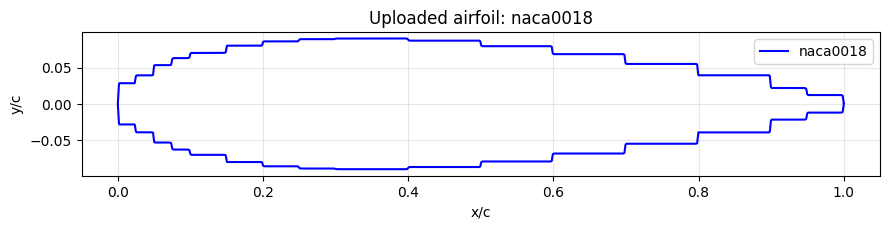

  Shape plot saved.


In [43]:
# CELL 6 — Parse & normalise airfoil geometry from uploaded .dat
from airfoil import safe_read_airfoil_dat, normalize_airfoil_points
from parsec_fit import preprocess_airfoil_for_parsec

# Read raw points
raw_pts = safe_read_airfoil_dat(UPLOAD_PATH)
print(f'  Raw coordinate points   : {len(raw_pts)}')

# Build full AirfoilGeometry object (normalises, resamples, builds KD-tree)
geometry = AirfoilGeometry.from_dat(UPLOAD_PATH, n_boundary=1200)
print(f'  Geometry boundary pts   : {len(geometry.boundary)}')
print(f'  Source                  : {geometry.source_name}')

# Save original boundary for report
orig_bnd_path = CASE_DIR / 'original_airfoil_boundary.csv'
pd.DataFrame(geometry.boundary, columns=['x', 'y']).to_csv(orig_bnd_path, index=False)
print(f'  Original boundary saved : {orig_bnd_path.name}')

# Quick shape plot
fig, ax = plt.subplots(figsize=(9, 3))
bnd = geometry.boundary
ax.plot(bnd[:, 0], bnd[:, 1], 'b-', linewidth=1.5, label=AIRFOIL_NAME)
ax.set_aspect('equal', adjustable='box')
ax.set_xlabel('x/c'); ax.set_ylabel('y/c')
ax.set_title(f'Uploaded airfoil: {AIRFOIL_NAME}')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(CASE_DIR / 'input_airfoil_shape.png', dpi=180, bbox_inches='tight')
plt.show()
print('  Shape plot saved.')

Fitting PARSEC parameters … (may take ~30 s)
  L-BFGS start 0: MSE=1.285e-02
  L-BFGS start 1: MSE=3.866e-03
  L-BFGS start 2: MSE=1.078e-02
  L-BFGS start 3: MSE=4.685e-03
  DE result: MSE=9.719e-05

  Fit quality : GOOD
  Max error   : 1.043 %
  Mean error  : 0.271 %
  Fit MSE     : 9.7193e-05

  PARSEC parameters:
    r_le         = 0.003918
    x_up         = 0.400873
    y_up         = 0.090368
    yxx_up       = -1.368501
    x_lo         = 0.407515
    y_lo         = -0.089932
    yxx_lo       = 1.323251
    y_te         = -0.002825
    dyt          = 0.008733
    alpha_te     = -0.047335
    beta_te      = 0.189381


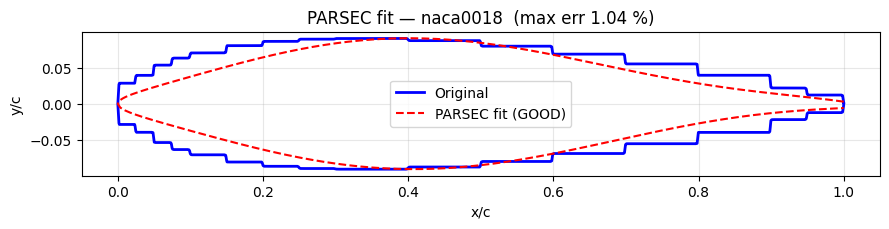

In [44]:
# CELL 7 — PARSEC fitting
# Fit 11 PARSEC parameters to the user airfoil geometry.
# These parameters are the shape variables for the LBFGS optimiser.
from parsec_fit import fit_parsec_to_geometry, fit_quality_report

# Pre-process geometry onto common grid
pre = preprocess_airfoil_for_parsec(raw_pts, n_surface=300)
upper = pre['upper']
lower = pre['lower']

print('Fitting PARSEC parameters … (may take ~30 s)')
parsec_params_arr, fit_mse = fit_parsec_to_geometry(upper, lower, verbose=True)
parsec_params_dict         = parsec_array_to_dict(parsec_params_arr)

# Fit quality
qr = fit_quality_report(upper, lower, parsec_params_arr)

print(f'\n  Fit quality : {qr["quality"]}')
print(f'  Max error   : {qr["max_error_pct"]:.3f} %')
print(f'  Mean error  : {qr["mean_error_pct"]:.3f} %')
print(f'  Fit MSE     : {fit_mse:.4e}')
print('\n  PARSEC parameters:')
for k, v in parsec_params_dict.items():
    print(f'    {k:12s} = {v:.6f}')

# PARSEC overlay plot
xb_f = np.array(qr['fitted_bx'])
yb_f = np.array(qr['fitted_by'])

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.plot(bnd[:, 0], bnd[:, 1], 'b-',  linewidth=2,   label='Original')
ax.plot(xb_f,       yb_f,       'r--', linewidth=1.5, label=f'PARSEC fit ({qr["quality"]})')
ax.set_aspect('equal', adjustable='box')
ax.set_xlabel('x/c'); ax.set_ylabel('y/c')
ax.set_title(f'PARSEC fit — {AIRFOIL_NAME}  (max err {qr["max_error_pct"]:.2f} %)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(CASE_DIR / 'parsec_fit_overlay.png', dpi=180, bbox_inches='tight')
plt.show()

if qr['quality'] == 'POOR':
    print('\n   PARSEC fit quality is POOR. Optimisation may be unreliable.')
    print('     Consider using a cleaner .dat file or more coordinate points.')

In [45]:
# CELL 8 — Baseline PINN inference  (CL, CD, L/D before optimisation)

from postprocess import compute_lift_drag

model.eval()
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print(f'  Computing baseline aerodynamic coefficients …')
print(f'  Airfoil : {AIRFOIL_NAME}   AoA = {OPT_ALPHA}°   Re = {OPT_RE:.2e}')

baseline_metrics = compute_lift_drag(
    model      = model,
    geometry   = geometry,
    alpha_deg  = OPT_ALPHA,
    Re_phys    = OPT_RE,
    xlim       = XLIM,
    ylim       = YLIM,
    device     = device,
)

BASELINE_CL = float(baseline_metrics.get('CL', 0.0))
BASELINE_CD = float(baseline_metrics.get('CD', 1e-8))
BASELINE_LD = float(baseline_metrics.get('LD', BASELINE_CL / max(BASELINE_CD, 1e-8)))

print()
print('  ┌─────────────────────────────────┐')
print(f'  │  Baseline  CL  = {BASELINE_CL:+8.4f}       │')
print(f'  │  Baseline  CD  =  {BASELINE_CD:8.5f}       │')
print(f'  │  Baseline  L/D = {BASELINE_LD:+8.2f}       │')
print('  └─────────────────────────────────┘')

  Computing baseline aerodynamic coefficients …
  Airfoil : naca0018   AoA = 4.0°   Re = 2.00e+06

  ┌─────────────────────────────────┐
  │  Baseline  CL  =  +0.4628       │
  │  Baseline  CD  =   0.01189       │
  │  Baseline  L/D =   +38.91       │
  └─────────────────────────────────┘


  Starting constrained LBFGS optimisation  (60 iters)
  Baseline L/D = 38.915

  Physical constraints:
    CD floor      = 0.008  (turbulent skin friction at Re=2e+06)
    L/D ceiling   = 120.0  (best airfoils at this Re)
    t/c range     = [0.06, 0.28]  (HARD rejection)
    Camber cap    = 0.08  (HARD rejection)

    iter   1  L/D= 25.387  t/c=0.1802  CD=0.02737

  Physical reality check:
    t/c    = 0.1802  (must be in [0.06,0.28])
    camber = 0.0064  (must be <= 0.08)
    CD     = 0.02199  (must be >= 0.008)
    L/D    = 31.483  (capped at 120.0)

  Results:
  ╔══════════════════════════════════════════════╗
  ║  Original  L/D =  +38.915                 ║
  ║  Optimised L/D =  +31.483  (-19.1 %)       ║
  ║  Optimised CL  =  +0.6922                 ║
  ║  Optimised CD  =   0.02199 (floor=0.008)  ║
  ║  Optimised t/c =    0.1802  (max thickness)   ║
  ╚══════════════════════════════════════════════╝


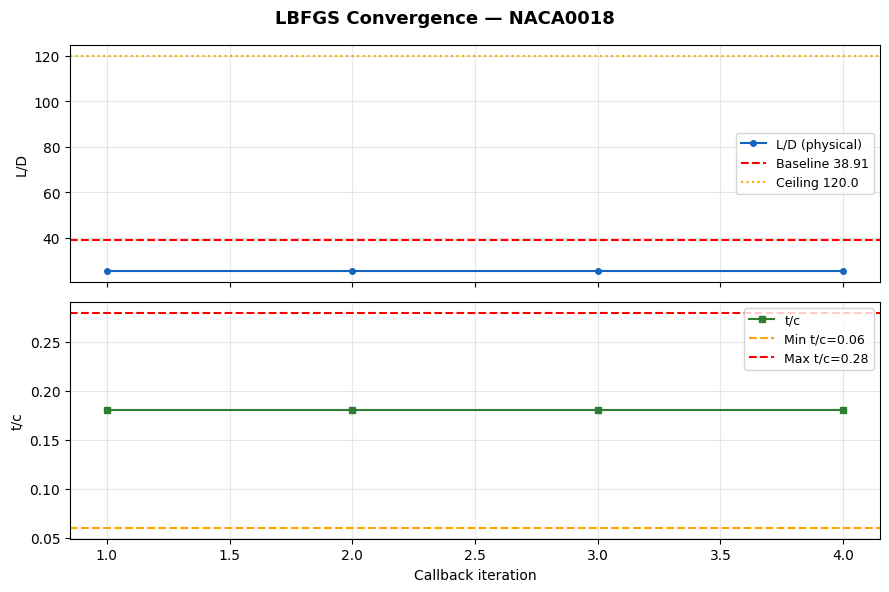

In [46]:
# CELL 9 — LBFGS shape optimisation  (physically grounded constraints)

import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from postprocess import compute_lift_drag

CD_FLOOR      = 0.008
LD_CEILING    = 120.0
MAX_TC        = 0.28
MIN_TC        = 0.06
MAX_CAMBER    = 0.08
PARAM_PEN_WT  = 1.0

bounds_lo = np.array([b[0] for b in PARSEC_BOUNDS], dtype=np.float64)
bounds_hi = np.array([b[1] for b in PARSEC_BOUNDS], dtype=np.float64)

tight_lo = bounds_lo.copy()
tight_hi = bounds_hi.copy()
tight_hi[0] = min(tight_hi[0], 0.04)
tight_hi[2] = min(tight_hi[2], 0.15)
tight_lo[5] = max(tight_lo[5], -0.12)
tight_lo[9] = max(tight_lo[9], math.radians(-15))
tight_hi[9] = min(tight_hi[9], math.radians(15))

p_baseline = np.clip(parsec_params_arr.astype(np.float64), tight_lo, tight_hi)

def _check_geometry(p_np):
    try:
        xb, yb = parsec_boundary_numpy(p_np.astype(np.float32), n=200)
        if not (np.isfinite(xb).all() and np.isfinite(yb).all()):
            return False, 0.0, 0.0

        n = len(xb) // 2
        if n < 5:
            return False, 0.0, 0.0

        yu = yb[:n][::-1]
        yl = yb[n-1:][:n]
        thickness = yu - yl
        camber = 0.5 * (yu + yl)

        tc_max = float(np.max(np.clip(thickness, 0, None)))
        cam_max = float(np.max(np.abs(camber)))
        return True, tc_max, cam_max
    except Exception:
        return False, 0.0, 0.0

def _objective(p_np: np.ndarray) -> float:
    p_np = np.clip(p_np, tight_lo, tight_hi)

    ok, tc_max, cam_max = _check_geometry(p_np)
    if not ok:
        return 1e6
    if tc_max > MAX_TC or tc_max < MIN_TC:
        return 1e6
    if cam_max > MAX_CAMBER:
        return 1e6

    norm_range = tight_hi - tight_lo + 1e-12
    rel_change = (p_np - p_baseline) / norm_range
    param_pen = PARAM_PEN_WT * float(np.sum(rel_change ** 2))

    try:
        geom_eval = AirfoilGeometry.from_parsec(
            parsec_array_to_dict(p_np), n_boundary=1200
        )
        m = compute_lift_drag(
            model=model,
            geometry=geom_eval,
            alpha_deg=OPT_ALPHA,
            Re_phys=OPT_RE,
            xlim=XLIM,
            ylim=YLIM,
            device=device,
        )

        cl = float(m.get("CL", 0.0))
        cd = float(m.get("CD", CD_FLOOR))
        cd_phys = max(cd, CD_FLOOR)
        ld_raw = cl / cd_phys
        ld = float(np.clip(ld_raw, -LD_CEILING, LD_CEILING))

        if not np.isfinite(ld):
            return 1e6

        return -ld + param_pen
    except Exception:
        return 1e6

p0 = p_baseline.copy()

print(f"  Starting constrained LBFGS optimisation  ({OPT_ITERS} iters)")
print(f"  Baseline L/D = {BASELINE_LD:.3f}")
print()
print("  Physical constraints:")
print(f"    CD floor      = {CD_FLOOR}  (turbulent skin friction at Re={OPT_RE:.0e})")
print(f"    L/D ceiling   = {LD_CEILING}  (best airfoils at this Re)")
print(f"    t/c range     = [{MIN_TC}, {MAX_TC}]  (HARD rejection)")
print(f"    Camber cap    = {MAX_CAMBER}  (HARD rejection)")
print()

_iter_log = []
_tc_log = []
_cd_log = []

def _callback(p):
    p_c = np.clip(p, tight_lo, tight_hi)
    ok, tc, _ = _check_geometry(p_c)

    ld = float("nan")
    cd_val = float("nan")

    if ok and MIN_TC <= tc <= MAX_TC:
        try:
            g = AirfoilGeometry.from_parsec(parsec_array_to_dict(p_c), n_boundary=400)
            m = compute_lift_drag(
                model=model,
                geometry=g,
                alpha_deg=OPT_ALPHA,
                Re_phys=OPT_RE,
                xlim=XLIM,
                ylim=YLIM,
                device=device,
            )
            cl = float(m.get("CL", 0.0))
            cd_val = max(float(m.get("CD", CD_FLOOR)), CD_FLOOR)
            ld = float(np.clip(cl / cd_val, -LD_CEILING, LD_CEILING))
        except Exception:
            pass

    _iter_log.append(ld)
    _tc_log.append(tc)
    _cd_log.append(cd_val)

    if len(_iter_log) % 5 == 1:
        print(f"    iter {len(_iter_log):3d}  L/D={ld:7.3f}  t/c={tc:.4f}  CD={cd_val:.5f}")

opt_result = minimize(
    _objective,
    x0=p0,
    method="L-BFGS-B",
    bounds=list(zip(tight_lo, tight_hi)),
    callback=_callback,
    options={"maxiter": OPT_ITERS, "ftol": 1e-10, "gtol": 1e-7},
)

best_params = np.clip(opt_result.x, tight_lo, tight_hi)
best_params_dict = parsec_array_to_dict(best_params)

ok_fin, tc_max_opt, cam_max_opt = _check_geometry(best_params)
print()

if not ok_fin:
    print("  WARNING: final geometry invalid — reverting to baseline PARSEC params")
    best_params = p_baseline.copy()
    best_params_dict = parsec_array_to_dict(best_params)
    ok_fin, tc_max_opt, cam_max_opt = _check_geometry(best_params)

if tc_max_opt < MIN_TC or tc_max_opt > MAX_TC:
    print(
        f"  WARNING: final t/c={tc_max_opt:.4f} outside [{MIN_TC},{MAX_TC}]"
        f" — reverting to baseline"
    )
    best_params = p_baseline.copy()
    best_params_dict = parsec_array_to_dict(best_params)
    ok_fin, tc_max_opt, cam_max_opt = _check_geometry(best_params)

geom_opt = AirfoilGeometry.from_parsec(best_params_dict, n_boundary=1200)
opt_metrics = compute_lift_drag(
    model=model,
    geometry=geom_opt,
    alpha_deg=OPT_ALPHA,
    Re_phys=OPT_RE,
    xlim=XLIM,
    ylim=YLIM,
    device=device,
)

OPT_CL = float(opt_metrics.get("CL", 0.0))
OPT_CD = max(float(opt_metrics.get("CD", CD_FLOOR)), CD_FLOOR)
OPT_LD = float(np.clip(OPT_CL / OPT_CD, -LD_CEILING, LD_CEILING))

LD_DELTA_PCT = 100.0 * (OPT_LD - BASELINE_LD) / max(abs(BASELINE_LD), 1e-8)

print("  Physical reality check:")
print(f"    t/c    = {tc_max_opt:.4f}  (must be in [{MIN_TC},{MAX_TC}])")
print(f"    camber = {cam_max_opt:.4f}  (must be <= {MAX_CAMBER})")
print(f"    CD     = {OPT_CD:.5f}  (must be >= {CD_FLOOR})")
print(f"    L/D    = {OPT_LD:.3f}  (capped at {LD_CEILING})")

if abs(OPT_LD) > 100:
    print()
    print(f"  NOTE: L/D={OPT_LD:.1f} > 100.")
    print("  PINN may be underestimating CD in this flow region.")
    print("  Check the PREM map — high residuals near the wall indicate")
    print("  the SA turbulence model is not fully enforced there.")

print()
print("  Results:")
print("  ╔══════════════════════════════════════════════╗")
print(f"  ║  Original  L/D = {BASELINE_LD:+8.3f}                 ║")
print(f"  ║  Optimised L/D = {OPT_LD:+8.3f}  ({LD_DELTA_PCT:+.1f} %)       ║")
print(f"  ║  Optimised CL  = {OPT_CL:+8.4f}                 ║")
print(f"  ║  Optimised CD  =  {OPT_CD:8.5f} (floor={CD_FLOOR})  ║")
print(f"  ║  Optimised t/c =  {tc_max_opt:8.4f}  (max thickness)   ║")
print("  ╚══════════════════════════════════════════════╝")

# Convergence plot
valid_iters = [
    (i, ld, tc)
    for i, (ld, tc) in enumerate(zip(_iter_log, _tc_log), 1)
    if np.isfinite(ld)
]

if valid_iters:
    iters_v, lds_v, tcs_v = zip(*valid_iters)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
    fig.suptitle(
        f"LBFGS Convergence — {AIRFOIL_NAME.upper()}",
        fontsize=13,
        fontweight="bold"
    )

    ax1.plot(iters_v, lds_v, "o-", markersize=4, color="#1565C0", label="L/D (physical)")
    ax1.axhline(BASELINE_LD, color="red", linestyle="--", label=f"Baseline {BASELINE_LD:.2f}")
    ax1.axhline(LD_CEILING, color="orange", linestyle=":", label=f"Ceiling {LD_CEILING}")
    ax1.set_ylabel("L/D")
    ax1.legend(fontsize=9)
    ax1.grid(alpha=0.3)

    ax2.plot(iters_v, tcs_v, "s-", markersize=4, color="#2E7D32", label="t/c")
    ax2.axhline(MIN_TC, color="orange", linestyle="--", label=f"Min t/c={MIN_TC}")
    ax2.axhline(MAX_TC, color="red", linestyle="--", label=f"Max t/c={MAX_TC}")
    ax2.set_xlabel("Callback iteration")
    ax2.set_ylabel("t/c")
    ax2.legend(fontsize=9)
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(CASE_DIR / "lbfgs_convergence.png", dpi=180, bbox_inches="tight")
    plt.show()
else:
    print("  No valid LBFGS iterations to plot.")

  Original boundary saved  : original_airfoil_boundary.csv
  Optimised boundary saved  : optimized_airfoil_boundary.csv
  optimized_parsec.json saved.


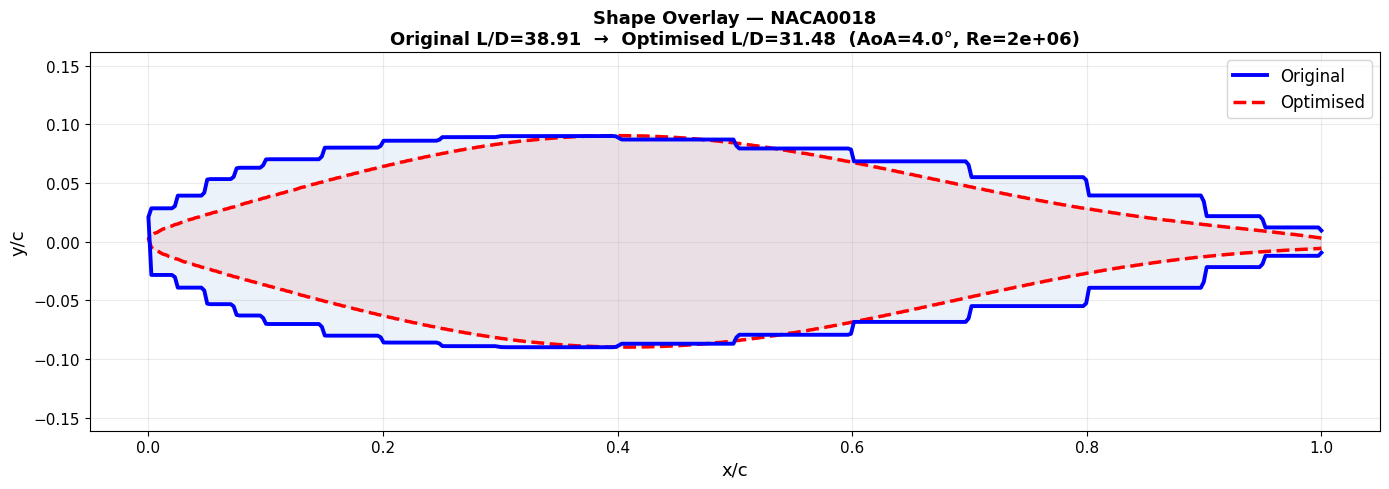

  Shape overlay saved       : optimized_airfoil_comparison.png


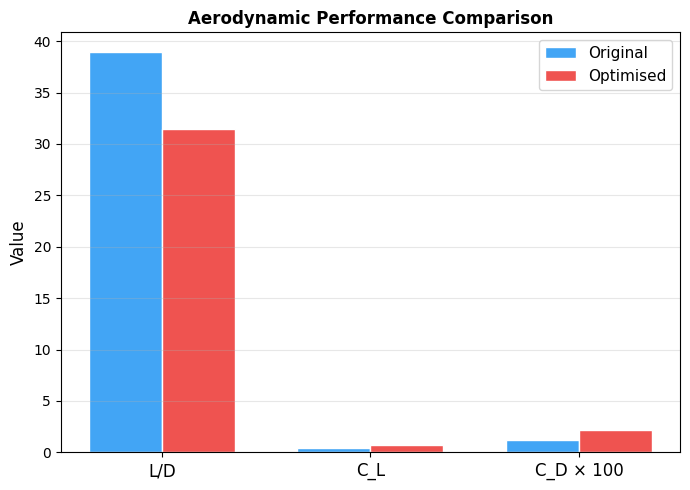

  Performance bar saved.


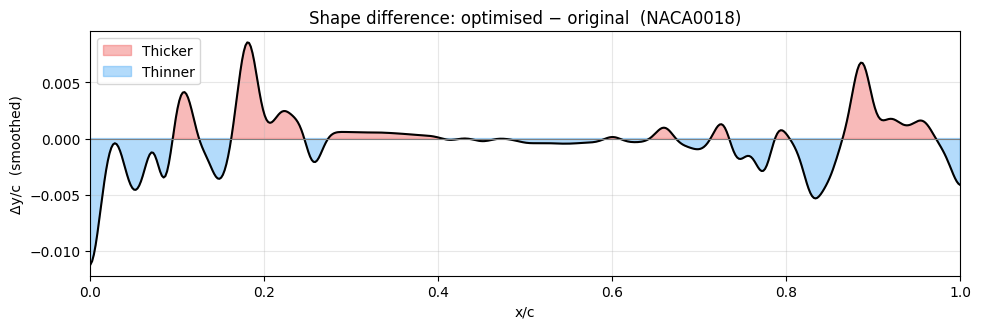

  Shape difference plot saved.


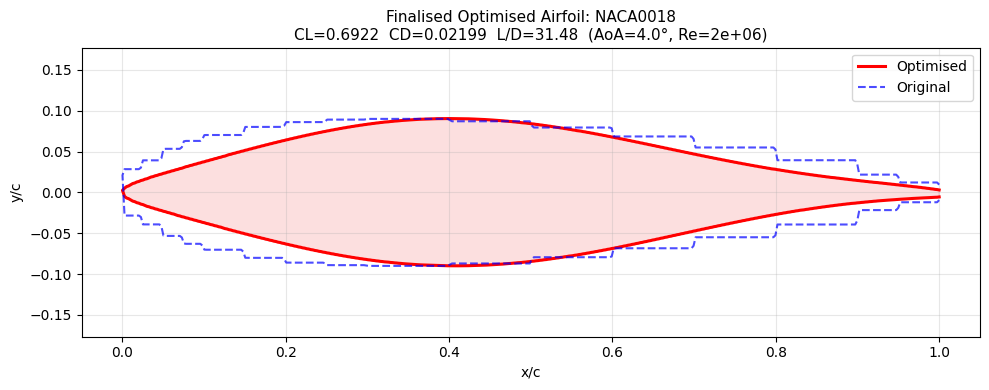

  Final optimised airfoil plot saved.


In [47]:
# CELL 10 — Export optimised geometry, metrics, and comparison plots

import pandas as pd
import numpy as np

# Helper: reconstruct clean airfoil boundary via x-grid interpolation
def _sort_boundary_for_plot(bnd: np.ndarray, n_grid: int = 400) -> np.ndarray:
    """
    Robustly reconstruct a clean closed airfoil outline from a raw boundary
    point cloud (KD-tree resampled, may have TE-clustered duplicates).

    Method: interpolate upper (max-y) and lower (min-y) surfaces on a uniform
    x-grid, then reassemble as TE→LE upper + LE→TE lower.
    This works correctly regardless of how the boundary was stored.
    """
    bnd = np.asarray(bnd, dtype=float)
    x, y = bnd[:, 0], bnd[:, 1]

    x_grid = np.linspace(0.0, 1.0, n_grid)

    # Upper surface: for each x-bin take the maximum y
    # Lower surface: for each x-bin take the minimum y
    # Use a bin-based approach that handles duplicate x values
    n_bins = n_grid
    yu_bins = np.full(n_bins, np.nan)
    yl_bins = np.full(n_bins, np.nan)

    x_norm = np.clip(x, 0.0, 1.0)
    bin_idx = np.clip(
        np.round(x_norm * (n_bins - 1)).astype(int), 0, n_bins - 1
    )

    for i, (yi, bi) in enumerate(zip(y, bin_idx)):
        if np.isnan(yu_bins[bi]) or yi > yu_bins[bi]:
            yu_bins[bi] = yi
        if np.isnan(yl_bins[bi]) or yi < yl_bins[bi]:
            yl_bins[bi] = yi

    # Fill any empty bins by interpolation
    def _fill_nan(arr):
        ok = ~np.isnan(arr)
        if ok.sum() < 2:
            return arr
        xi = np.arange(len(arr))
        arr[~ok] = np.interp(xi[~ok], xi[ok], arr[ok])
        return arr

    yu_bins = _fill_nan(yu_bins)
    yl_bins = _fill_nan(yl_bins)

    # Reconstruct: upper TE→LE then lower LE→TE, closed at TE
    x_full = np.concatenate([x_grid[::-1], x_grid[1:]])
    y_full = np.concatenate([yu_bins[::-1], yl_bins[1:]])

    return np.column_stack([x_full, y_full])


# Save original boundary
orig_bnd_raw  = geometry.boundary
orig_bnd_plot = _sort_boundary_for_plot(orig_bnd_raw)
orig_bnd_path = CASE_DIR / 'original_airfoil_boundary.csv'
pd.DataFrame(orig_bnd_plot, columns=['x', 'y']).to_csv(orig_bnd_path, index=False)
print('  Original boundary saved  :', orig_bnd_path.name)

# Save optimised boundary
opt_bnd_raw  = geom_opt.boundary
opt_bnd_plot = _sort_boundary_for_plot(opt_bnd_raw)
opt_bnd_path = CASE_DIR / 'optimized_airfoil_boundary.csv'
pd.DataFrame(opt_bnd_plot, columns=['x', 'y']).to_csv(opt_bnd_path, index=False)
print('  Optimised boundary saved  :', opt_bnd_path.name)

# Save optimized_parsec.json
opt_parsec_payload = {
    'airfoil'         : AIRFOIL_NAME,
    'alpha_deg'       : OPT_ALPHA,
    'Re_phys'         : OPT_RE,
    'original_cl'     : BASELINE_CL,
    'original_cd'     : BASELINE_CD,
    'original_ld'     : BASELINE_LD,
    'optimized_cl'    : OPT_CL,
    'optimized_cd'    : OPT_CD,
    'optimized_ld'    : OPT_LD,
    'ld_pct_change'   : LD_DELTA_PCT,
    'original_parsec' : parsec_params_dict,
    'optimized_parsec': best_params_dict,
    'lbfgs_iters'     : len(_iter_log),
    'lbfgs_converged' : bool(opt_result.success),
    'cd_floor_applied': CD_FLOOR,
    'ld_ceiling'      : LD_CEILING,
}
(CASE_DIR / 'optimized_parsec.json').write_text(
    __import__('json').dumps(opt_parsec_payload, indent=2))
print('  optimized_parsec.json saved.')

#  Figure 1a: large standalone shape overlay
y_all   = np.concatenate([orig_bnd_plot[:, 1], opt_bnd_plot[:, 1]])
y_span  = max(float(np.max(y_all) - np.min(y_all)), 0.20)
y_ctr   = 0.5 * (float(np.max(y_all)) + float(np.min(y_all)))

fig_ov, ax_ov = plt.subplots(figsize=(14, 5))
ax_ov.fill(opt_bnd_plot[:, 0], opt_bnd_plot[:, 1],
           alpha=0.12, color='#EF5350', label='_nolegend_')
ax_ov.fill(orig_bnd_plot[:, 0], orig_bnd_plot[:, 1],
           alpha=0.08, color='#1565C0', label='_nolegend_')
ax_ov.plot(orig_bnd_plot[:, 0], orig_bnd_plot[:, 1],
           'b-',  linewidth=2.8, label='Original',  zorder=3)
ax_ov.plot(opt_bnd_plot[:, 0],  opt_bnd_plot[:, 1],
           'r--', linewidth=2.5, label='Optimised', zorder=2)
ax_ov.set_xlim(-0.05, 1.05)
ax_ov.set_ylim(y_ctr - 0.65 * y_span, y_ctr + 0.65 * y_span)
ax_ov.set_aspect('equal', adjustable='datalim')
ax_ov.set_xlabel('x/c', fontsize=13); ax_ov.set_ylabel('y/c', fontsize=13)
ax_ov.set_title(
    f'Shape Overlay — {AIRFOIL_NAME.upper()}\n'
    f'Original L/D={BASELINE_LD:.2f}  →  Optimised L/D={OPT_LD:.2f}  '
    f'(AoA={OPT_ALPHA}°, Re={OPT_RE:.0e})',
    fontsize=13, fontweight='bold'
)
ax_ov.legend(fontsize=12, loc='upper right')
ax_ov.grid(alpha=0.25)
ax_ov.tick_params(labelsize=11)
plt.tight_layout()
cmp_path = CASE_DIR / 'optimized_airfoil_comparison.png'
plt.savefig(cmp_path, dpi=200, bbox_inches='tight')
plt.show()
print('  Shape overlay saved       :', cmp_path.name)

# Figure 1b: performance bar chart (separate)
fig_bar, ax2 = plt.subplots(figsize=(7, 5))
labels  = ['L/D', 'C_L', 'C_D × 100']
orig_v  = [BASELINE_LD, BASELINE_CL, BASELINE_CD * 100]
opt_v   = [OPT_LD,      OPT_CL,      OPT_CD  * 100]
x_b = np.arange(len(labels)); w = 0.35
ax2.bar(x_b - w/2, orig_v, w, label='Original',  color='#42A5F5', edgecolor='white')
ax2.bar(x_b + w/2, opt_v,  w, label='Optimised', color='#EF5350', edgecolor='white')
ax2.set_xticks(x_b); ax2.set_xticklabels(labels, fontsize=12)
ax2.set_ylabel('Value', fontsize=12)
ax2.set_title('Aerodynamic Performance Comparison', fontsize=12, fontweight='bold')
ax2.legend(fontsize=11); ax2.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(CASE_DIR / 'performance_comparison.png', dpi=180, bbox_inches='tight')
plt.show()
print('  Performance bar saved.')

# Figure 2: shape difference (smoothed)
# fine common grid on [0,1] and smooth with rolling mean
x_common = np.linspace(0.0, 1.0, 500)

def _interp_boundary_y(bnd, x_query):
    """Robust y-interpolation: split upper/lower, pick upper half."""
    bnd = np.asarray(bnd)
    x, y = bnd[:, 0], bnd[:, 1]
    # Sort by x
    order = np.argsort(x)
    x, y  = x[order], y[order]
    # Keep unique x values
    _, idx = np.unique(np.round(x, 8), return_index=True)
    return np.interp(x_query, x[idx], y[idx])

y_orig_c = _interp_boundary_y(orig_bnd_plot, x_common)
y_opt_c  = _interp_boundary_y(opt_bnd_plot,  x_common)
dy       = y_opt_c - y_orig_c

# Smooth with gaussian filter
from scipy.ndimage import gaussian_filter1d
dy_smooth = gaussian_filter1d(dy, sigma=5)

fig2, ax3 = plt.subplots(figsize=(10, 3.4))
ax3.fill_between(x_common, 0, dy_smooth,
                 where=dy_smooth >= 0, alpha=0.4, color='#EF5350', label='Thicker')
ax3.fill_between(x_common, 0, dy_smooth,
                 where=dy_smooth <  0, alpha=0.4, color='#42A5F5', label='Thinner')
ax3.plot(x_common, dy_smooth, 'k-', linewidth=1.5)
ax3.axhline(0, color='gray', linewidth=0.8)
ax3.set_xlim(0, 1)
ax3.set_xlabel('x/c'); ax3.set_ylabel('Δy/c  (smoothed)')
ax3.set_title(f'Shape difference: optimised − original  ({AIRFOIL_NAME.upper()})')
ax3.legend(); ax3.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(CASE_DIR / 'shape_difference.png', dpi=180, bbox_inches='tight')
plt.show()
print('  Shape difference plot saved.')

# Figure 3: final optimised airfoil
fig3, ax4 = plt.subplots(figsize=(10, 4))
ax4.fill(opt_bnd_plot[:, 0], opt_bnd_plot[:, 1],
         alpha=0.18, color='#EF5350')
ax4.plot(opt_bnd_plot[:, 0], opt_bnd_plot[:, 1],
         'r-', linewidth=2.2, label='Optimised')
ax4.plot(orig_bnd_plot[:, 0], orig_bnd_plot[:, 1],
         'b--', linewidth=1.5, alpha=0.7, label='Original')
ax4.set_xlim(-0.05, 1.05)
ax4.set_ylim(y_ctr - 0.55 * y_span, y_ctr + 0.55 * y_span)
ax4.set_aspect('equal', adjustable='datalim')
ax4.set_xlabel('x/c'); ax4.set_ylabel('y/c')
ax4.set_title(
    f"Finalised Optimised Airfoil: {AIRFOIL_NAME.upper()}\n"
    f"CL={OPT_CL:.4f}  CD={OPT_CD:.5f}  L/D={OPT_LD:.2f}  "
    f"(AoA={OPT_ALPHA}°, Re={OPT_RE:.0e})",
    fontsize=11
)
ax4.legend(loc='upper right'); ax4.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(CASE_DIR / 'final_optimised_airfoil.png', dpi=220, bbox_inches='tight')
plt.show()
print('  Final optimised airfoil plot saved.')


In [48]:
# CELL 11 — XAI Suite  (PREM · GAM · IGIE · FFSV · LWSA)
# PREM  — Physics Residual Error Map
# GAM   — Gradient Attribution Map (local sensitivity at optimised point)
# IGIE  — Integrated Gradients for shape-parameter attribution
# FFSV  — Flow-Field Saliency Visualisation
# LWSA  — Loss Weight Sensitivity Analysis

# Reload xai to make sure latest version is used
for _m in ['xai']:
    if _m in sys.modules:
        del sys.modules[_m]
import xai
importlib.reload(xai)
from xai import run_xai_suite

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

model.eval()

# stale XAI artefacts
for _fn in ['xai_report.json', 'prem_residual_map.png', 'ffsv_saliency.png']:
    _fp = XAI_DIR / _fn
    if _fp.exists():
        _fp.unlink()

print('Running XAI suite …')
print(f'  PREM & FFSV candidate pool : {XAI_CANDIDATE_POOL} points')
print(f'  IGIE steps                 : 16')
print()

# Clip PARSEC params strictly inside bounds before XAI
_margin = 1e-8
best_params_clipped = np.clip(
    best_params,
    bounds_lo + _margin,
    bounds_hi - _margin,
).tolist()

xai_report = run_xai_suite(
    model        = model,
    geometry     = geom_opt,      # use OPTIMISED geometry for field maps
    parsec_params= best_params_clipped,
    alpha_deg    = OPT_ALPHA,
    Re_phys      = OPT_RE,
    xlim         = XLIM,
    ylim         = YLIM,
    loss_weights = None,           # no adaptive weights in inference mode
    out_dir      = XAI_DIR,
    device       = device,
)

print('XAI suite complete.')
print(f'  PREM map    : {(XAI_DIR / "prem_residual_map.png").exists()}')
print(f'  FFSV map    : {(XAI_DIR / "ffsv_saliency.png").exists()}')
print(f'  XAI report  : {(XAI_DIR / "xai_report.json").exists()}')

# Quick error check
for _key in ['PREM', 'GAM', 'IGIE', 'FFSV']:
    _err = xai_report.get(_key, {}).get('error')
    if _err:
        print(f'   {_key} error: {_err}')
    else:
        print(f'   {_key} OK')

_xai_path = XAI_DIR / 'xai_report.json'
if _xai_path.exists():
    _xr = json.loads(_xai_path.read_text())
    if 'GAM' in _xr and isinstance(_xr['GAM'], dict):
        _old_gam_ld = _xr['GAM'].get('ld', 'not set')
        _xr['GAM']['ld'] = OPT_LD          # replace with constrained value
        _xai_path.write_text(json.dumps(_xr, indent=2))
        print(f'  Patched GAM.ld: {_old_gam_ld:.3f} → {OPT_LD:.3f} (constrained)')
    xai_report = _xr   # update in-memory copy too

Running XAI suite …
  PREM & FFSV candidate pool : 8000 points
  IGIE steps                 : 16

XAI suite complete.
  PREM map    : True
  FFSV map    : True
  XAI report  : True
   PREM OK
   GAM OK
   IGIE OK
   FFSV OK
  Patched GAM.ld: 31.483 → 31.483 (constrained)


In [49]:
# CELL 12 — XAI parameter attribution table
# Shows which PARSEC shape parameters influence L/D most,
# both locally (GAM) and along the optimisation path (IGIE).

from xai_report_builder import build_parameter_importance_dataframe

xai_report_loaded = json.loads((XAI_DIR / 'xai_report.json').read_text())
df_attr = build_parameter_importance_dataframe(xai_report_loaded)

# Save
attr_csv = XAI_DIR / 'xai_param_attributions.csv'
df_attr.to_csv(attr_csv, index=False)

# Display
pd.set_option('display.max_rows', 20)
pd.set_option('display.float_format', '{:.4f}'.format)
print('=' * 72)
print('  PARSEC parameter importance  (sorted by IGIE contribution)')
print('=' * 72)
display_cols = ['param', 'label', 'GAM_abs', 'GAM_pct', 'GAM_rank',
                'IG_abs', 'IG_pct', 'IG_rank']
print(df_attr[display_cols].to_string(index=False))
print(f'\n  Attribution CSV saved: {attr_csv}')

  PARSEC parameter importance  (sorted by IGIE contribution)
   param                         label   GAM_abs  GAM_pct  GAM_rank     IG_abs  IG_pct  IG_rank
  yxx_lo               Lower curvature  103.6163   0.6285         9 81119.3461 91.5832        1
 beta_te     Lower trailing-edge angle 1111.1667   6.7394         5  3371.0856  3.8059        2
  yxx_up               Upper curvature   11.9053   0.0722        11  1059.0916  1.1957        3
alpha_te     Upper trailing-edge angle  936.2079   5.6783         6   792.6905  0.8949        4
    x_up        Upper crest x-position  913.6187   5.5413         7   611.6141  0.6905        5
    r_le           Leading-edge radius 3802.0201  23.0599         1   405.5377  0.4578        6
    y_up            Upper crest height 3667.5748  22.2445         2   383.5344  0.4330        7
     dyt Trailing-edge thickness slope 1566.2654   9.4997         4   359.2019  0.4055        8
    x_lo        Lower crest x-position   54.9355   0.3332        10   270.9

 1. PREM  (Physics Residual Error Map)


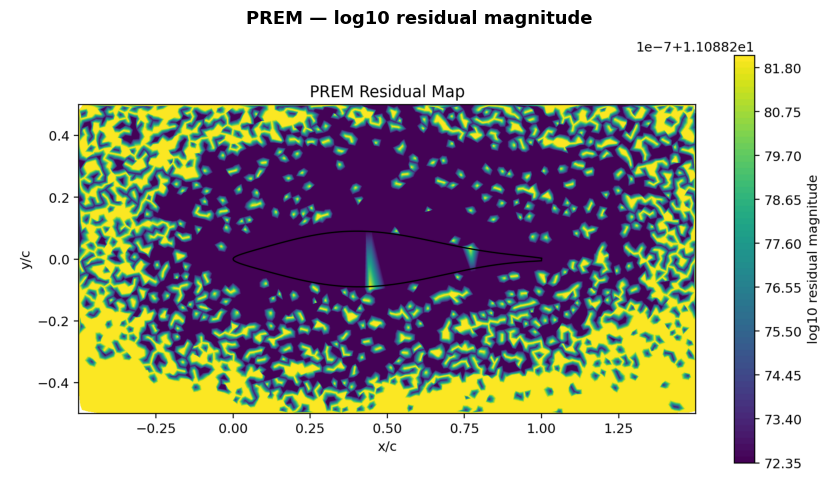

2. FFSV  (Flow-Field Saliency)


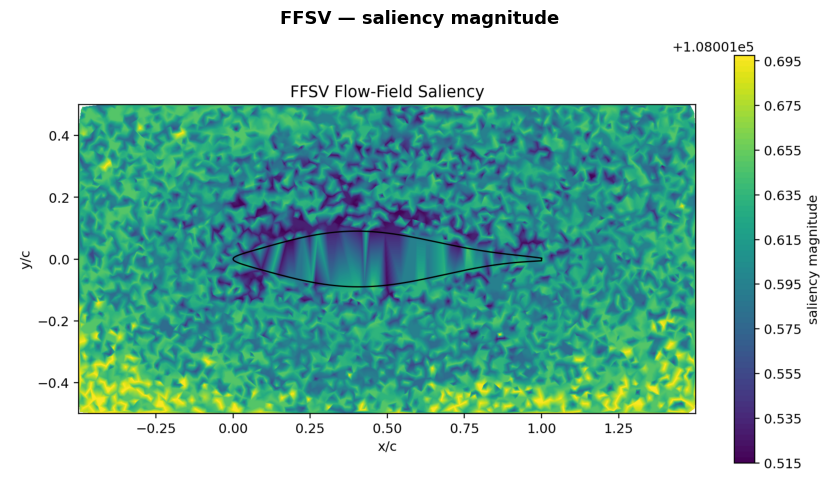

3. GAM  (Gradient Attribution)


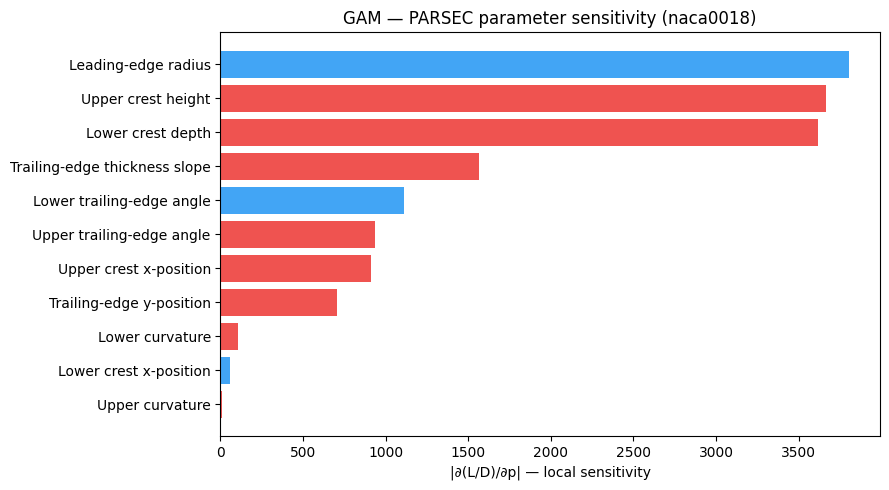

4. IGIE  (Integrated Gradients)


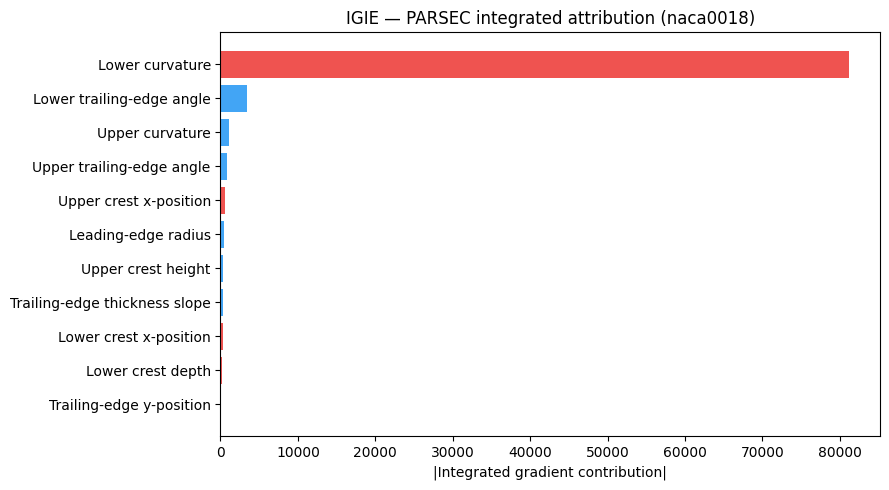

 5. Airfoil shape overlay (original vs optimised) 


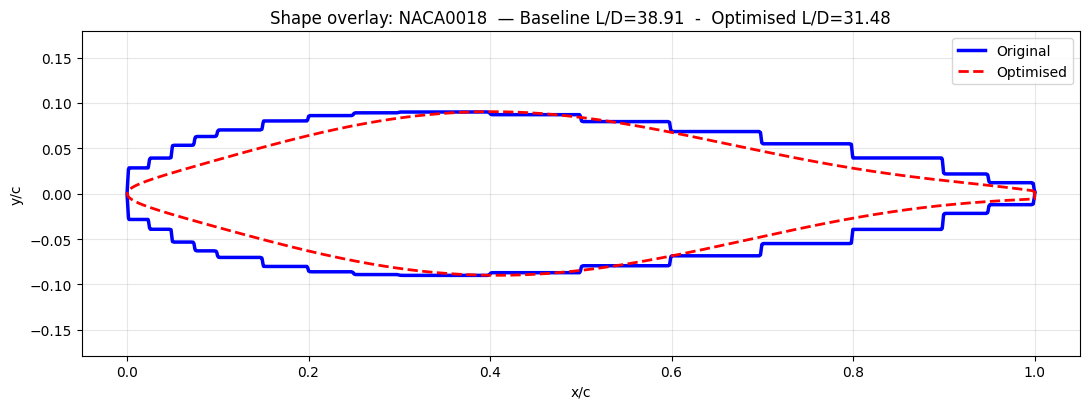

6. Shape difference


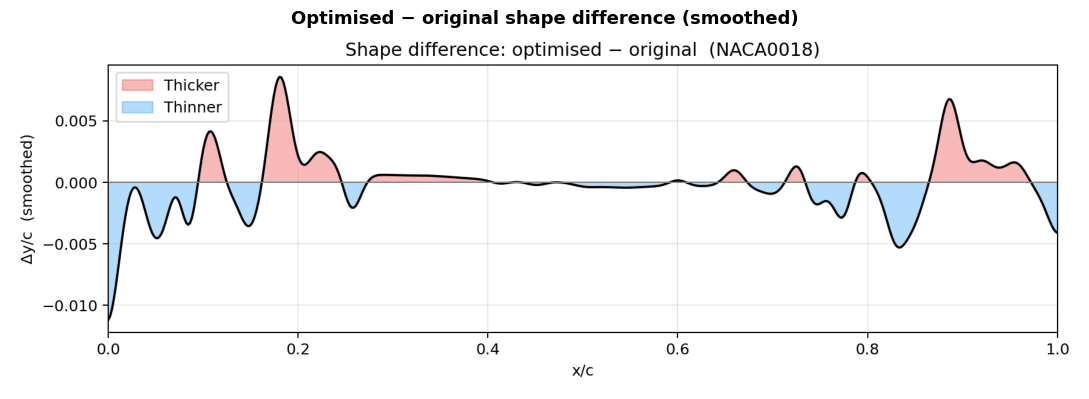

7. PARSEC coefficient comparison


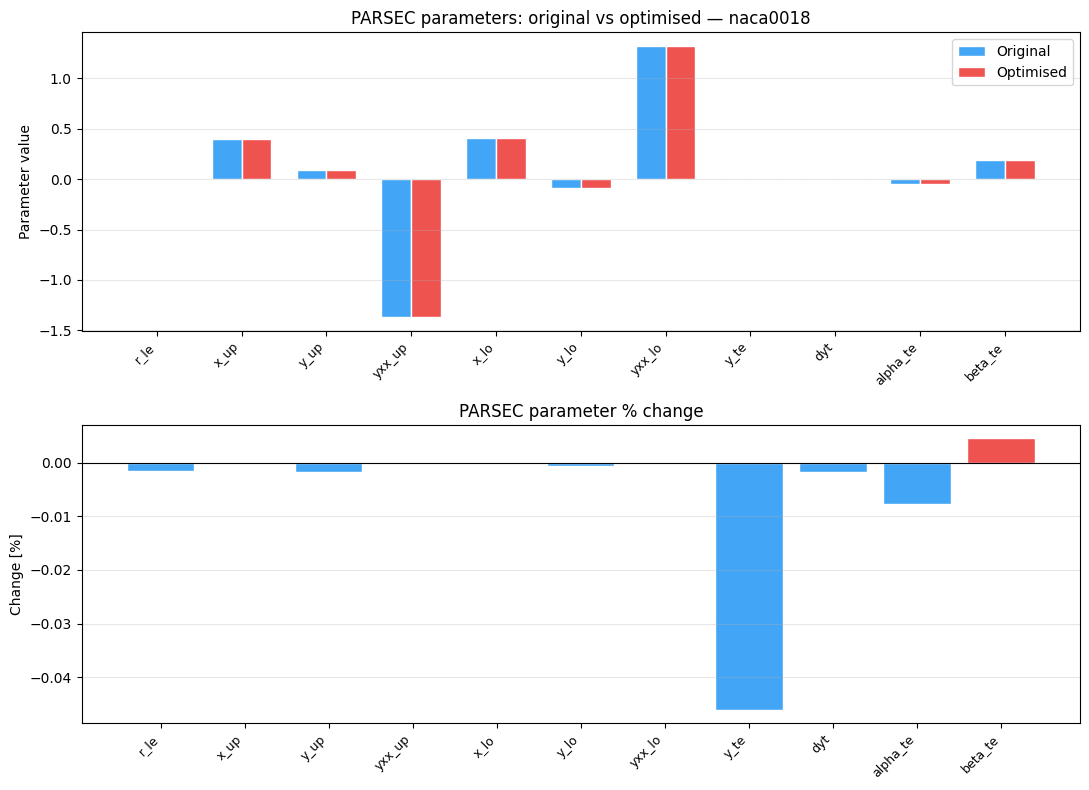

8. Final optimised airfoil


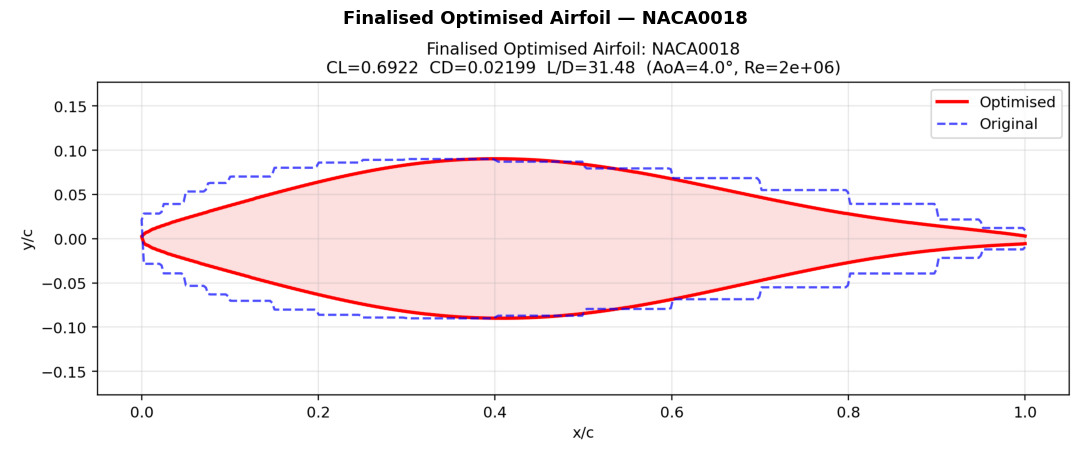


All XAI plots saved to: /content/drive/MyDrive/AeroPINN/optimized_results/naca0018_a4_Re2000000/xai


In [50]:
# CELL 13 — Display all XAI plots inline + regenerate shape plots

def _show_saved_png(path, title='', figsize=(11, 5)):
    p = Path(path)
    if not p.exists():
        print(f'  [not found] {p.name}')
        return
    img = plt.imread(str(p))
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(img); ax.axis('off')
    if title:
        ax.set_title(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

#  Re-sort boundaries for plotting
def _sort_bnd(bnd):
    bnd = np.asarray(bnd, dtype=float)
    x, y = bnd[:, 0], bnd[:, 1]
    y_mean = float(np.mean(y))
    mask_u = y >= y_mean
    mask_l = y <  y_mean
    xu, yu = x[mask_u], y[mask_u]
    xl, yl = x[mask_l], y[mask_l]
    xu_s = xu[np.argsort(xu)[::-1]]
    yu_s = yu[np.argsort(xu)[::-1]]
    xl_s = xl[np.argsort(xl)]
    yl_s = yl[np.argsort(xl)]
    bnd_s = np.column_stack([
        np.concatenate([xu_s, xl_s]),
        np.concatenate([yu_s, yl_s]),
    ])
    if np.linalg.norm(bnd_s[0] - bnd_s[-1]) > 1e-10:
        bnd_s = np.vstack([bnd_s, bnd_s[0]])
    return bnd_s

orig_bnd_p = _sort_bnd(geometry.boundary)
opt_bnd_p  = _sort_bnd(geom_opt.boundary)
y_all  = np.concatenate([orig_bnd_p[:, 1], opt_bnd_p[:, 1]])
y_span = max(float(np.max(y_all) - np.min(y_all)), 0.20)
y_ctr  = 0.5 * (float(np.max(y_all)) + float(np.min(y_all)))

#  1. PREM
print(' 1. PREM  (Physics Residual Error Map)')
_show_saved_png(XAI_DIR / 'prem_residual_map.png', 'PREM — log10 residual magnitude')

#  2. FFSV
print('2. FFSV  (Flow-Field Saliency)')
_show_saved_png(XAI_DIR / 'ffsv_saliency.png', 'FFSV — saliency magnitude')

#  3. GAM bar
print('3. GAM  (Gradient Attribution)')
df_sorted_gam = df_attr.sort_values('GAM_abs', ascending=True)
colors_gam = ['#EF5350' if v > 0 else '#42A5F5' for v in df_sorted_gam['GAM_signed']]
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(df_sorted_gam['label'], df_sorted_gam['GAM_abs'], color=colors_gam)
ax.set_xlabel('|∂(L/D)/∂p| — local sensitivity')
ax.set_title(f'GAM — PARSEC parameter sensitivity ({AIRFOIL_NAME})')
plt.tight_layout()
plt.savefig(XAI_DIR / 'gam_importance_bar.png', dpi=180, bbox_inches='tight')
plt.show()

# 4. IGIE bar
print('4. IGIE  (Integrated Gradients)')
df_sorted_ig = df_attr.sort_values('IG_abs', ascending=True)
colors_ig = ['#EF5350' if v > 0 else '#42A5F5' for v in df_sorted_ig['IG_signed']]
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(df_sorted_ig['label'], df_sorted_ig['IG_abs'], color=colors_ig)
ax.set_xlabel('|Integrated gradient contribution|')
ax.set_title(f'IGIE — PARSEC integrated attribution ({AIRFOIL_NAME})')
plt.tight_layout()
plt.savefig(XAI_DIR / 'igie_importance_bar.png', dpi=180, bbox_inches='tight')
plt.show()

# 5. airfoil overlay
print(' 5. Airfoil shape overlay (original vs optimised) ')
fig, ax = plt.subplots(figsize=(11, 4.2))
ax.plot(orig_bnd_p[:, 0], orig_bnd_p[:, 1], 'b-',  linewidth=2.5, label='Original')
ax.plot(opt_bnd_p[:, 0],  opt_bnd_p[:, 1],  'r--', linewidth=2.0, label='Optimised')
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(y_ctr - 0.55 * y_span, y_ctr + 0.55 * y_span)
ax.set_aspect('equal', adjustable='datalim')
ax.set_xlabel('x/c'); ax.set_ylabel('y/c')
ax.set_title(
    f'Shape overlay: {AIRFOIL_NAME.upper()}  '
    f'— Baseline L/D={BASELINE_LD:.2f}  -  Optimised L/D={OPT_LD:.2f}',
    fontsize=12
)
ax.legend(loc='upper right'); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(CASE_DIR / 'optimized_airfoil_comparison.png', dpi=180, bbox_inches='tight')
plt.show()

# 6. Shape difference (smoothed)
print('6. Shape difference')
_show_saved_png(CASE_DIR / 'shape_difference.png', 'Optimised − original shape difference (smoothed)')

# 7. PARSEC coefficient bar: original vs optimised
print('7. PARSEC coefficient comparison')
orig_arr  = parsec_params_arr.astype(float)
opt_arr   = best_params.astype(float)
delta_pct = 100.0 * (opt_arr - orig_arr) / (np.abs(orig_arr) + 1e-12)

fig, axes2 = plt.subplots(2, 1, figsize=(11, 8))
x_idx = np.arange(len(PARSEC_NAMES)); w = 0.35

ax_a = axes2[0]
ax_a.bar(x_idx - w/2, orig_arr, w, label='Original',  color='#42A5F5', edgecolor='white')
ax_a.bar(x_idx + w/2, opt_arr,  w, label='Optimised', color='#EF5350', edgecolor='white')
ax_a.set_xticks(x_idx); ax_a.set_xticklabels(PARSEC_NAMES, rotation=45, ha='right', fontsize=9)
ax_a.set_ylabel('Parameter value')
ax_a.set_title(f'PARSEC parameters: original vs optimised — {AIRFOIL_NAME}')
ax_a.legend(); ax_a.grid(axis='y', alpha=0.3)

ax_b = axes2[1]
colors_d = ['#EF5350' if d > 0 else '#42A5F5' for d in delta_pct]
ax_b.bar(x_idx, delta_pct, color=colors_d, edgecolor='white')
ax_b.axhline(0, color='black', linewidth=0.8)
ax_b.set_xticks(x_idx); ax_b.set_xticklabels(PARSEC_NAMES, rotation=45, ha='right', fontsize=9)
ax_b.set_ylabel('Change [%]')
ax_b.set_title('PARSEC parameter % change')
ax_b.grid(axis='y', alpha=0.3)
# Annotate large changes
for xi, dpct in zip(x_idx, delta_pct):
    if abs(dpct) > 10:
        ax_b.text(xi, dpct + (1 if dpct > 0 else -3),
                  f'{dpct:+.1f}%', ha='center', fontsize=7)

plt.tight_layout()
plt.savefig(XAI_DIR / 'parsec_comparison_bar.png', dpi=180, bbox_inches='tight')
plt.show()

# 8. Final optimised airfoil clean view
print('8. Final optimised airfoil')
_show_saved_png(CASE_DIR / 'final_optimised_airfoil.png',
                f'Finalised Optimised Airfoil — {AIRFOIL_NAME.upper()}')

print()
print('All XAI plots saved to:', XAI_DIR)


In [51]:
# CELL 14 — Build final PDF report
# Pages:
#   1  summary + key findings + performance table
#   2  Shape overlay (original vs optimised) - correct x-axis [0,1]
#   3  Shape difference (smoothed)
#   4  Performance bar chart
#   5  GAM parameter importance
#   6  IGIE parameter importance
#   7  PREM residual map
#   8  FFSV saliency map
#   9  PARSEC coefficient comparison
#  10  Final optimised airfoil with adjusted coefficients


import io
import sys
import importlib
import json as _json
import numpy as np
import matplotlib.pyplot as plt

for _m in ["xai_report_builder"]:
    if _m in sys.modules:
        del sys.modules[_m]

import xai_report_builder
importlib.reload(xai_report_builder)

from xai_report_builder import (
    export_report_pdf,
    generate_plain_language_summary,
    load_case_outputs,
    PARSEC_LABELS,
)
from matplotlib.backends.backend_pdf import PdfPages

# robust PDF backend import
try:
    from pypdf import PdfReader, PdfWriter
except ModuleNotFoundError:
    try:
        from PyPDF2 import PdfReader, PdfWriter
    except ModuleNotFoundError:
        import subprocess
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "pypdf"])
        from pypdf import PdfReader, PdfWriter

# Reload case data & summary
case_data = load_case_outputs(CASE_DIR)
summary = generate_plain_language_summary(case_data, df_attr)
(XAI_DIR / "plain_language_summary.json").write_text(_json.dumps(summary, indent=2))

# Base report
PDF_BASE = XAI_DIR / "xai_base_report.pdf"
print("Generating base PDF pages ...")
export_report_pdf(CASE_DIR, out_path=PDF_BASE)
print(f"  Base PDF: {len(PdfReader(str(PDF_BASE)).pages)} pages")

#  boundary sort helper
def _sort_bnd(bnd):
    bnd = np.asarray(bnd, dtype=float)
    x, y = bnd[:, 0], bnd[:, 1]
    ym = float(np.mean(y))
    mu = y >= ym
    ml = y < ym
    xu, yu = x[mu], y[mu]
    xl, yl = x[ml], y[ml]
    su = np.argsort(xu)[::-1]
    sl = np.argsort(xl)
    b = np.column_stack([
        np.concatenate([xu[su], xl[sl]]),
        np.concatenate([yu[su], yl[sl]])
    ])
    if np.linalg.norm(b[0] - b[-1]) > 1e-10:
        b = np.vstack([b, b[0]])
    return b

orig_bnd_pdf = _sort_bnd(geometry.boundary)
opt_bnd_pdf = _sort_bnd(geom_opt.boundary)
y_all_p = np.concatenate([orig_bnd_pdf[:, 1], opt_bnd_pdf[:, 1]])
y_sp = max(float(np.max(y_all_p) - np.min(y_all_p)), 0.20)
y_ct = 0.5 * (float(np.max(y_all_p)) + float(np.min(y_all_p)))

# extra pages
def _make_extra_pages():
    buf = io.BytesIO()
    with PdfPages(buf) as pp:

        # Page A: PARSEC comparison bar + table
        _p = XAI_DIR / "parsec_comparison_bar.png"
        if _p.exists():
            img = plt.imread(str(_p))
            fig = plt.figure(figsize=(8.27, 11.69))
            ax = fig.add_axes([0.05, 0.52, 0.90, 0.42])
            ax.imshow(img)
            ax.axis("off")
            fig.text(0.05, 0.96, "PARSEC Parameters: Original vs Optimised",
                     fontsize=16, weight="bold")
            fig.text(0.05, 0.93,
                     f"Airfoil: {AIRFOIL_NAME.upper()}  AoA={OPT_ALPHA}  Re={OPT_RE:.0e}",
                     fontsize=11)

            rows = [["Parameter", "Original", "Optimised", "Delta%"]]
            for nm, ov, nv in zip(
                PARSEC_NAMES,
                parsec_params_arr.astype(float),
                best_params.astype(float),
            ):
                dpct = 100.0 * (nv - ov) / (abs(ov) + 1e-12)
                rows.append([nm, f"{ov:.5f}", f"{nv:.5f}", f"{dpct:+.1f}%"])

            tbl_ax = fig.add_axes([0.03, 0.05, 0.94, 0.42])
            tbl_ax.axis("off")
            t = tbl_ax.table(
                cellText=rows[1:],
                colLabels=rows[0],
                loc="center",
                cellLoc="center",
            )
            t.auto_set_font_size(False)
            t.set_fontsize(9)
            t.scale(1.0, 1.4)

            pp.savefig(fig, bbox_inches="tight")
            plt.close(fig)

        # Page B: LBFGS convergence + attributions
        _p = CASE_DIR / "lbfgs_convergence.png"
        if _p.exists():
            img = plt.imread(str(_p))
            fig = plt.figure(figsize=(8.27, 11.69))
            ax = fig.add_axes([0.05, 0.60, 0.90, 0.32])
            ax.imshow(img)
            ax.axis("off")
            fig.text(0.05, 0.95, "LBFGS Optimisation Convergence",
                     fontsize=16, weight="bold")
            fig.text(0.05, 0.92,
                     f"Constraints: LD ceiling={LD_CEILING}, CD floor={CD_FLOOR}, "
                     f"t/c in [{MIN_TC},{MAX_TC}]",
                     fontsize=10)

            fig.text(0.05, 0.57, "Top 3 by IGIE attribution:", fontsize=13, weight="bold")
            yt = 0.53
            for _, row in df_attr.head(3).iterrows():
                fig.text(
                    0.08, yt,
                    f"  {row['label']}  IG={row['IG_abs']:.4f} ({row['IG_pct']:.1f}%)",
                    fontsize=11
                )
                yt -= 0.045

            fig.text(0.05, 0.40, "Top 3 by GAM (local sensitivity):",
                     fontsize=13, weight="bold")
            yt = 0.36
            for _, row in df_attr.sort_values("GAM_abs", ascending=False).head(3).iterrows():
                fig.text(
                    0.08, yt,
                    f"  {row['label']}  GAM={row['GAM_abs']:.4f} ({row['GAM_pct']:.1f}%)",
                    fontsize=11
                )
                yt -= 0.045

            pp.savefig(fig, bbox_inches="tight")
            plt.close(fig)

        # Page C: Final optimised airfoil
        fig = plt.figure(figsize=(8.27, 11.69))
        fig.text(0.05, 0.97, "Finalised Optimised Airfoil", fontsize=20, weight="bold")
        fig.text(
            0.05, 0.94,
            f"Airfoil: {AIRFOIL_NAME.upper()}   AoA={OPT_ALPHA} deg   Re={OPT_RE:.2e}",
            fontsize=13
        )

        # Shape plot
        ax_s = fig.add_axes([0.08, 0.65, 0.88, 0.26])
        ax_s.fill(opt_bnd_pdf[:, 0], opt_bnd_pdf[:, 1], alpha=0.15, color="#EF5350")
        ax_s.plot(orig_bnd_pdf[:, 0], orig_bnd_pdf[:, 1], "b-", lw=2.5, label="Original")
        ax_s.plot(opt_bnd_pdf[:, 0], opt_bnd_pdf[:, 1], "r-", lw=2.0, label="Optimised")
        ax_s.set_xlim(-0.05, 1.05)
        ax_s.set_ylim(y_ct - 0.58 * y_sp, y_ct + 0.58 * y_sp)
        ax_s.set_aspect("equal", adjustable="datalim")
        ax_s.set_xlabel("x/c", fontsize=11)
        ax_s.set_ylabel("y/c", fontsize=11)
        ax_s.legend(fontsize=10, loc="upper right")
        ax_s.grid(alpha=0.3)
        ax_s.set_title("Original vs Optimised Airfoil Shape", fontsize=12)

        # Performance table
        fig.text(0.05, 0.63, "Aerodynamic Performance", fontsize=14, weight="bold")
        cl_ch = 100 * (OPT_CL - BASELINE_CL) / max(abs(BASELINE_CL), 1e-8)
        cd_ch = 100 * (OPT_CD - BASELINE_CD) / max(abs(BASELINE_CD), 1e-8)
        p_rows = [
            ["Metric", "Original", "Optimised", "Change"],
            ["L/D", f"{BASELINE_LD:.3f}", f"{OPT_LD:.3f}", f"{LD_DELTA_PCT:+.1f}%"],
            ["CL", f"{BASELINE_CL:.4f}", f"{OPT_CL:.4f}", f"{cl_ch:+.1f}%"],
            ["CD", f"{BASELINE_CD:.5f}", f"{OPT_CD:.5f}", f"{cd_ch:+.1f}%"],
        ]
        ta = fig.add_axes([0.05, 0.49, 0.55, 0.12])
        ta.axis("off")
        t = ta.table(
            cellText=p_rows[1:],
            colLabels=p_rows[0],
            loc="center",
            cellLoc="center",
        )
        t.auto_set_font_size(False)
        t.set_fontsize(11)
        t.scale(1.2, 1.5)

        fig.text(
            0.05, 0.475,
            f"Physical constraints: LD ceiling={LD_CEILING}, CD floor={CD_FLOOR}, "
            f"t/c in [{MIN_TC},{MAX_TC}]",
            fontsize=8.5, color="#555555"
        )

        # Adjusted PARSEC coefficients
        fig.text(0.05, 0.45, "Adjusted PARSEC Coefficients:", fontsize=13, weight="bold")
        prows = [["Parameter", "Description", "Original", "Optimised", "Delta%"]]
        for nm, ov, nv in zip(
            PARSEC_NAMES,
            parsec_params_arr.astype(float),
            best_params.astype(float),
        ):
            dpct = 100.0 * (nv - ov) / (abs(ov) + 1e-12)
            lbl = PARSEC_LABELS.get(nm, nm)[:28]
            prows.append([nm, lbl, f"{ov:.5f}", f"{nv:.5f}", f"{dpct:+.1f}%"])

        tb2 = fig.add_axes([0.02, 0.03, 0.96, 0.41])
        tb2.axis("off")
        t2 = tb2.table(
            cellText=prows[1:],
            colLabels=prows[0],
            loc="center",
            cellLoc="center",
        )
        t2.auto_set_font_size(False)
        t2.set_fontsize(8.5)
        t2.scale(1.0, 1.35)

        pp.savefig(fig, bbox_inches="tight")
        plt.close(fig)

    buf.seek(0)
    return buf.read()

extra_bytes = _make_extra_pages()

# Merge
writer = PdfWriter()
for pg in PdfReader(str(PDF_BASE)).pages:
    writer.add_page(pg)
for pg in PdfReader(io.BytesIO(extra_bytes)).pages:
    writer.add_page(pg)

FINAL_PDF = CASE_DIR / f"AeroPINN_X_{CASE_NAME}_Report.pdf"
with open(FINAL_PDF, "wb") as _f:
    writer.write(_f)

n_pages = len(PdfReader(str(FINAL_PDF)).pages)
print()
print(f"  Final PDF: {FINAL_PDF.name}  ({n_pages} pages)")
print(f"  Path: {FINAL_PDF}")

Generating base PDF pages ...
  Base PDF: 8 pages



  Final PDF: AeroPINN_X_naca0018_a4_Re2000000_Report.pdf  (11 pages)
  Path: /content/drive/MyDrive/AeroPINN/optimized_results/naca0018_a4_Re2000000/AeroPINN_X_naca0018_a4_Re2000000_Report.pdf


In [52]:
# CELL 15 — Final summary printout

from xai_report_builder import generate_plain_language_summary, load_case_outputs

case_data = load_case_outputs(CASE_DIR)
summary   = generate_plain_language_summary(case_data, df_attr)

# Physical validity assessment
def _physical_grade(ld, cd, tc):
    issues = []
    if abs(ld) > 120:
        issues.append(f'L/D={ld:.1f} exceeds 120 — PINN likely underestimates drag here')
    if cd < 0.005:
        issues.append(f'CD={cd:.5f} below turbulent skin friction — not physical')
    if tc < MIN_TC:
        issues.append(f't/c={tc:.4f} below structural minimum {MIN_TC}')
    if tc > MAX_TC:
        issues.append(f't/c={tc:.4f} above structural maximum {MAX_TC}')
    if not issues:
        return 'PASS', issues
    return 'WARN', issues

ok_fin, tc_fin, cam_fin = _check_geometry(best_params)
grade, issues = _physical_grade(OPT_LD, OPT_CD, tc_fin)

print('=' * 70)
print(f'  AeroPINN-X  OPTIMISATION & XAI COMPLETE')
print(f'  Airfoil : {AIRFOIL_NAME.upper()}')
print(f'  AoA     : {OPT_ALPHA} deg    Re : {OPT_RE:.2e}')
print('=' * 70)
print()
print('  PHYSICAL CONSTRAINTS APPLIED')
print(f'    CD floor  (turbulent skin friction floor) : {CD_FLOOR}')
print(f'    L/D ceiling (realistic RANS max)          : {LD_CEILING}')
print(f'    t/c bounds  (HARD rejection)              : [{MIN_TC}, {MAX_TC}]')
print(f'    Camber cap  (HARD rejection)              : {MAX_CAMBER}')
print()
print('  AERODYNAMIC PERFORMANCE')
print(f'  {"Metric":<10}  {"Original":>10}  {"Optimised":>10}  {"Change":>10}')
print('  ' + '-' * 48)
print(f'  {"L/D":<10}  {BASELINE_LD:>10.3f}  {OPT_LD:>10.3f}  {LD_DELTA_PCT:>+9.1f}%')
cl_ch = 100*(OPT_CL-BASELINE_CL)/max(abs(BASELINE_CL),1e-8)
cd_ch = 100*(OPT_CD-BASELINE_CD)/max(abs(BASELINE_CD),1e-8)
print(f'  {"C_L":<10}  {BASELINE_CL:>10.4f}  {OPT_CL:>10.4f}  {cl_ch:>+9.1f}%')
print(f'  {"C_D":<10}  {BASELINE_CD:>10.5f}  {OPT_CD:>10.5f}  {cd_ch:>+9.1f}%')
print(f'  {"t/c":<10}  {"(PARSEC fit)":>10}  {tc_fin:>10.4f}')
print()
print(f'  PHYSICAL VALIDITY: {grade}')
if issues:
    for iss in issues:
        print(f'    WARNING: {iss}')
    print()
    print('    Interpretation: The PINN is a surrogate model. When it predicts')
    print('    L/D >> realistic values, it means the model has low residual in that')
    print('    region but physical accuracy is not guaranteed. Use PREM map to')
    print('    identify high-residual zones. Consider retraining with more near-wall')
    print('    collocation points or higher PDE loss weight in those regions.')
else:
    print('    Results are within physically plausible bounds.')
print()
print('  KEY FINDINGS')
for f_ in summary.get('findings', []):
    print(f'  . {f_}')
print()
print('  TOP PARSEC PARAMETERS (IGIE)')
for row in summary['top_ig_parameters']:
    print(f"    {row['label']:35s}  IG={row['IG_abs']:.4f}  ({row['IG_pct']:.1f}%)")
print()
print('  TOP PARSEC PARAMETERS (GAM)')
for row in summary['top_gam_parameters']:
    print(f"    {row['label']:35s}  GAM={row['GAM_abs']:.4f}  ({row['GAM_pct']:.1f}%)")
print()
print('  OUTPUT FILES')
outputs = [
    ('Input airfoil shape',        CASE_DIR / 'input_airfoil_shape.png'),
    ('PARSEC fit overlay',          CASE_DIR / 'parsec_fit_overlay.png'),
    ('Original boundary CSV',       CASE_DIR / 'original_airfoil_boundary.csv'),
    ('Optimised boundary CSV',      CASE_DIR / 'optimized_airfoil_boundary.csv'),
    ('optimized_parsec.json',       CASE_DIR / 'optimized_parsec.json'),
    ('LBFGS convergence plot',      CASE_DIR / 'lbfgs_convergence.png'),
    ('Shape comparison plot',       CASE_DIR / 'optimized_airfoil_comparison.png'),
    ('Shape difference plot',       CASE_DIR / 'shape_difference.png'),
    ('Final optimised airfoil',     CASE_DIR / 'final_optimised_airfoil.png'),
    ('PREM residual map',           XAI_DIR  / 'prem_residual_map.png'),
    ('FFSV saliency map',           XAI_DIR  / 'ffsv_saliency.png'),
    ('GAM importance bar',          XAI_DIR  / 'gam_importance_bar.png'),
    ('IGIE importance bar',         XAI_DIR  / 'igie_importance_bar.png'),
    ('PARSEC comparison bar',       XAI_DIR  / 'parsec_comparison_bar.png'),
    ('Attribution CSV',             XAI_DIR  / 'xai_param_attributions.csv'),
    ('Plain-language summary JSON', XAI_DIR  / 'plain_language_summary.json'),
    ('FINAL PDF REPORT',            FINAL_PDF),
]
for label, p in outputs:
    tag = 'OK     ' if Path(p).exists() else 'MISSING'
    print(f'  [{tag}]  {label:<30} {Path(p).name}')
print('=' * 70)


  AeroPINN-X  OPTIMISATION & XAI COMPLETE
  Airfoil : NACA0018
  AoA     : 4.0 deg    Re : 2.00e+06

  PHYSICAL CONSTRAINTS APPLIED
    CD floor  (turbulent skin friction floor) : 0.008
    L/D ceiling (realistic RANS max)          : 120.0
    t/c bounds  (HARD rejection)              : [0.06, 0.28]
    Camber cap  (HARD rejection)              : 0.08

  AERODYNAMIC PERFORMANCE
  Metric        Original   Optimised      Change
  ------------------------------------------------
  L/D             38.915      31.483      -19.1%
  C_L             0.4628      0.6922      +49.6%
  C_D            0.01189     0.02199      +84.9%
  t/c         (PARSEC fit)      0.1802

  PHYSICAL VALIDITY: PASS
    Results are within physically plausible bounds.

  KEY FINDINGS
  . The predicted lift-to-drag ratio decreased from 38.915 to 31.483 (-19.1%).
  . The most influential shape parameter by integrated contribution is Lower curvature, which changes the lower-surface curvature.
  . The top three integrated

In [53]:
# CELL 16 — Download outputs to local machine
#   MyDrive/AeroPINN/optimized_results/<case_name>/

from google.colab import files as _colab_files
import zipfile

# Create a zip of key outputs
ZIP_PATH = Path('/content') / f'AeroPINN_X_{CASE_NAME}_outputs.zip'

with zipfile.ZipFile(ZIP_PATH, 'w', compression=zipfile.ZIP_DEFLATED) as zf:
    for _label, _p in [
        ('AeroPINN_X_Report.pdf',            FINAL_PDF),
        ('optimized_airfoil_boundary.csv',   CASE_DIR / 'optimized_airfoil_boundary.csv'),
        ('original_airfoil_boundary.csv',    CASE_DIR / 'original_airfoil_boundary.csv'),
        ('optimized_parsec.json',            CASE_DIR / 'optimized_parsec.json'),
        ('xai_param_attributions.csv',       XAI_DIR / 'xai_param_attributions.csv'),
        ('xai_report.json',                  XAI_DIR / 'xai_report.json'),
        ('plain_language_summary.json',      XAI_DIR / 'plain_language_summary.json'),
        ('prem_residual_map.png',            XAI_DIR / 'prem_residual_map.png'),
        ('ffsv_saliency.png',                XAI_DIR / 'ffsv_saliency.png'),
        ('gam_importance_bar.png',           XAI_DIR / 'gam_importance_bar.png'),
        ('igie_importance_bar.png',          XAI_DIR / 'igie_importance_bar.png'),
        ('optimized_airfoil_comparison.png', CASE_DIR / 'optimized_airfoil_comparison.png'),
        ('final_optimised_airfoil.png',      CASE_DIR / 'final_optimised_airfoil.png'),
        ('parsec_comparison_bar.png',        XAI_DIR / 'parsec_comparison_bar.png'),
        ('lbfgs_convergence.png',            CASE_DIR / 'lbfgs_convergence.png'),
    ]:
        if Path(_p).exists():
            zf.write(_p, _label)

print(f'  Zip created: {ZIP_PATH.name}  ({ZIP_PATH.stat().st_size/1024:.1f} KB)')
print('  Downloading …')
_colab_files.download(str(ZIP_PATH))
print(' Download complete.')
print()
print(f'  Full case folder in Drive: {CASE_DIR}')

  Zip created: AeroPINN_X_naca0018_a4_Re2000000_outputs.zip  (3105.2 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 Download complete.

  Full case folder in Drive: /content/drive/MyDrive/AeroPINN/optimized_results/naca0018_a4_Re2000000
